In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("placement.csv")

In [11]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model**

Why Split the Dataset?

If we train and test on the same data:

model may simply memorize answers
performance appears very high
but fails on new real-world data

Testing set helps measure:

real accuracy
generalization ability
Common Split Ratio
Training	Testing
80%	20%
70%	30%

Example:

Total data = 1000 rows
800 → training
200 → testing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


iloc in pandas is used to select rows and columns using integer index.

df.iloc[row_index , column_index]

eg---> df.iloc[0] this will access 0th index row
eg---> df.iloc[:1] this will access 1th index row
eg---> df.iloc[0:1] this will access element at 0th row and 1th column


df.drop("column_name", axis=1) ---> drops the column . axis=1 means we want to drop a column.

In [7]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [8]:
import matplotlib.pyplot as plt

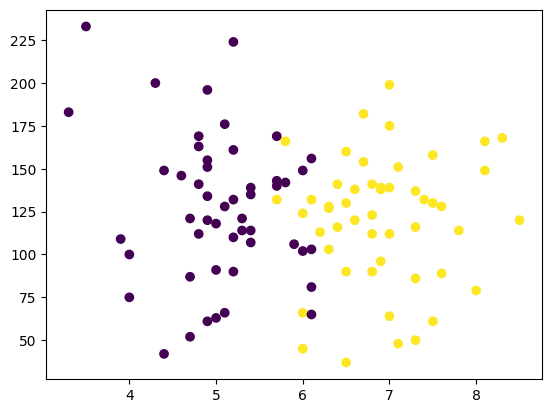

In [18]:
plt.scatter(x=df["cgpa"],y=df["iq"],c=df["placement"])

scikit-learn Logistic Regression tries to draw a decision boundary that separates two classes.

For 2 features, that boundary is usually a straight line.

Example:

0 → not placed
1 → placed

In [9]:
x=df.iloc[:,0:2] # independet variables / input variables ---> gives all rows and column from 0 to 2(2 is excluded)
y=df.iloc[:,-1] # alll rows and last column ---> last column index is -1 ( negative indexing)
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [10]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

| Term                 | Meaning                                       |
| -------------------- | --------------------------------------------- |
| `train_test_split()` | Splits dataset into training and testing data |
| `X`                  | Input features                                |
| `y`                  | Target/output column                          |
| `X_train`            | Features used for training                    |
| `X_test`             | Features used for testing                     |
| `y_train`            | Output labels for training                    |
| `y_test`             | Output labels for testing                     |
| `test_size=0.2`      | 20% data used for testing                     |
| `train_size=0.8`     | 80% data used for training                    |
| `random_state=42`    | Produces same split every run                 |
| `shuffle=True`       | Randomly shuffles data before split           |
| Purpose              | Checks model performance on unseen data       |


In [13]:
x_train

,cgpa,iq
34,4.8,163.0
59,4.8,112.0
44,7.5,61.0
4,5.8,142.0
89,4.9,151.0
...,...,...
95,4.3,200.0
11,6.9,138.0
10,6.0,45.0
20,6.6,120.0


In [14]:
y_train

,placement
34,0
59,0
44,1
4,0
89,0
...,...
95,0
11,1
10,1
20,1


In [15]:
x_test

,cgpa,iq
71,6.1,132.0
26,7.0,199.0
91,7.5,158.0
21,7.1,151.0
54,6.4,141.0
33,6.0,149.0
92,5.2,110.0
99,6.2,113.0
22,4.9,120.0
58,8.0,79.0


In [16]:
y_test

,placement
71,1
26,1
91,1
21,1
54,1
33,0
92,0
99,1
22,0
58,1


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()

In [19]:
x_train=scaler.fit_transform(x_train)

In [20]:
x_train

array([[-0.9733513 ,  0.95410025],
       [-0.9733513 , -0.25482181],
       [ 1.36269181, -1.46374386],
       [-0.10815014,  0.45630882],
       [-0.88683118,  0.669648  ],
       [ 0.1514102 ,  0.78816977],
       [ 0.32445043,  0.1007435 ],
       [-0.88683118,  1.73634393],
       [-1.31943176, -1.91412659],
       [ 0.75705101,  0.00592609],
       [-0.62727083, -0.77631759],
       [-0.54075072, -0.2074131 ],
       [ 0.1514102 , -1.36892645],
       [-2.27115302,  1.42818733],
       [ 0.49749066, -0.77631759],
       [-1.66551222, -0.53927405],
       [ 1.18965158, -0.87113501],
       [ 2.22789297, -0.06518697],
       [ 0.06489009, -0.49186535],
       [-1.31943176,  0.62223929],
       [-0.62727083,  0.90669154],
       [ 0.93009124, -1.3926308 ],
       [ 0.75705101,  0.43260446],
       [ 0.84357112, -0.63409147],
       [-0.88683118, -1.46374386],
       [-0.80031107, -0.75261324],
       [ 1.44921193,  0.12444786],
       [-1.05987141, -1.67708305],
       [ 2.05485273,

In [21]:
x_test=scaler.fit_transform(x_test)

In [22]:
x_test

array([[-0.15173671,  0.18434391],
       [ 0.72931517,  2.60611678],
       [ 1.21878844,  1.12413636],
       [ 0.82720983,  0.87111532],
       [ 0.14194725,  0.50965668],
       [-0.24963137,  0.79882359],
       [-1.0327886 , -0.6108651 ],
       [-0.05384206, -0.50242751],
       [-1.32647256, -0.24940646],
       [ 1.70826171, -1.73138688],
       [-0.24963137, -0.10482301],
       [ 0.63142052,  0.43736495],
       [-0.83699929, -0.71930269],
       [ 1.5124724 , -0.46628164],
       [-1.13068325,  0.03976045],
       [ 1.21878844,  0.11205218],
       [-1.22857791, -2.3097207 ],
       [-1.52226187, -0.2132606 ],
       [-0.93489395, -0.2132606 ],
       [ 0.72931517,  0.43736495]])

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model=LogisticRegression()

In [25]:
model.fit(x_train,y_train) #trains the model

LogisticRegression()

In [26]:
y_predict=model.predict(x_test) # prediction made by my model

In [27]:
y_predict

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1])

In [28]:
y_test # actual ans

,placement
71,1
26,1
91,1
21,1
54,1
33,0
92,0
99,1
22,0
58,1


In [3]:
# calculating accuracy score
from sklearn.metrics import accuracy_score

ModuleNotFoundError: No module named 'sklearn'

In [30]:
accuracy_score(y_test,y_predict)

0.85

In [31]:
from mlxtend.plotting import plot_decision_regions # Used to visualize classification boundaries.

<Axes: >

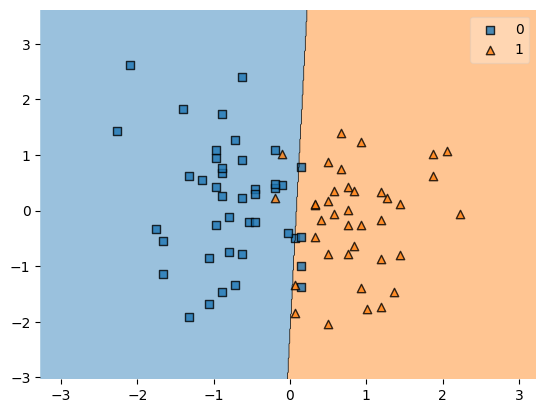

In [32]:
plot_decision_regions(x_train, y_train.values, clf=model)

In [1]:
import pickle

In [2]:
pickle.dump(model,open('model.pkl','wb'))

NameError: name 'model' is not defined